In [1]:
import os
import glob
from datasets.metadata import uci_datasets_info
import pickle
from functools import reduce
from functools import partial
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from scipy.stats import chi2
from datasets.metadata import uci_datasets_info
from utils.process_data import preprocess_dataframe
from utils.measures import *
from utils.clustering import *
from Walker import ActiveDPGMMWalker
import pygad

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from matplotlib.patches import Patch
from adjustText import adjust_text
from pandas.plotting import parallel_coordinates
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

/home/bdezoysa/.conda/envs/py310/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK


In [2]:
overall_bests = []

for name in uci_datasets_info.keys():
    # if name == 'winequality-red':
    #     continue
    
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [512, 1024, 2048]

    measure = 'jsd'
    is_all_done = True
    best_of_each = []
    for pocket_size in pocket_sizes:
        file = f'./results/rebuttal/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)

                best_ratio = -float('inf')
                best_i = 0
                # for i in range(3):
                #     ratio = results['best_scores'][i] / len(results['best_details'][i]['clusters'])
                #     if ratio > best_ratio:
                #         best_ratio = ratio
                #         best_i = i

                best_of_each.append([results['best_scores'][best_i], results['best_details'][best_i], results['best_configs'][best_i], pocket_size])
        else:
            is_all_done = False
            break
    
    if is_all_done:
        the_best = max(best_of_each, key=lambda x: x[0])
        the_row = [name, pocket_size]
        the_row.extend(the_best[2][1:])
        overall_bests.append(the_row)

        with open(f'./results/rebuttal/{name}_{measure}_overall_best.pkl', 'wb') as f:
            pickle.dump(
                {
                    'best_score': the_best[0],
                    'best_detail': the_best[1],
                    'best_config': the_best[2],
                    'pocket_size': the_best[3]
                }, f)

In [2]:
rows = [['dataset', 'jsd', 'kld', 'hellinger', 'tvd']]
for name in uci_datasets_info.keys():
    print(name)
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [512, 1024, 2048]

    the_best = []
    for measure in ['jsd', 'kld', 'hellinger', 'tvd']:
        is_all_done = True
        best_of_each = []
        for pocket_size in pocket_sizes:
            file = f'./results/rebuttal/{name}_p{pocket_size}_{measure}.pkl'
            if os.path.isfile(file):
                # print(file)
                with open(file, 'rb') as f:
                    results = pickle.load(f)
                    # the_values = [results['best_scores'][0]]
                    # the_values.extend(list(results['best_configs'][0])[1:])
                    # best_of_each.append(the_values)
                    # best_ratio = -float('inf')
                    # best_i = -1
                    # for i in range(3):
                    #     # ratio = results['best_scores'][i] / len(results['best_details'][i]['clusters'])
                    #     # if ratio > best_ratio and results['best_configs'][i][3] > 0.0:
                    #     #     best_ratio = ratio
                    #     #     best_i = i
                    #     # else:
                    #     #     print('0 equivalent')

                    #     if results['best_configs'][i][3] > 0.0:
                    #         best_i = i
                        
                    # if best_i == -1:
                    #     print('0 equivalent')

                    # best_i = 0
                    # best_of_each.append(results['best_scores'][best_i])

                    # print(len(results['best_details'][best_i]['clusters']))
                    # print(results['best_configs'][best_i])

                    summary_df = pd.DataFrame(results['summary'][1:], columns=results['summary'][0])
                    filtered_summary_df = summary_df[(summary_df['lambda'] > 0.0)] # & (summary_df['num_clusters'] < 100)]
                    # filtered_summary_df['ratio'] = filtered_summary_df['score'] / filtered_summary_df['num_clusters']

                    # best_of_each.append(filtered_summary_df[filtered_summary_df['score'] == filtered_summary_df['score'].max()]['score'].iloc[0])

                    best_of_each.append(filtered_summary_df['score'].mean())
            else:   
                is_all_done = False
                break
        
        if is_all_done:
            # the_best.append(max(best_of_each, key=lambda x: x[0]))
            # print(the_best[-1])
            the_best.append(max(best_of_each))
            # the_best.append(sum(best_of_each) / len(best_of_each))
            print(f'{pocket_size} done.')
    
    if len(the_best) == 4:
        new_row = [name]
        new_row.extend(the_best)
        rows.append(new_row)

sepsis_survival_primary_cohort
2048 done.
2048 done.
2048 done.
2048 done.
social_network_ads
32 done.
32 done.
32 done.
32 done.
uk_used_cars_ford
64 done.
64 done.
64 done.
64 done.
combined_cycle_power_plant
32 done.
32 done.
32 done.
32 done.
protein_tertiary_structure
64 done.
64 done.
64 done.
64 done.
gas_turbine_emissions
64 done.
64 done.
64 done.
64 done.
naval_propulsion_plants
64 done.
64 done.
64 done.
64 done.
winequality-red


32 done.
32 done.
32 done.
32 done.
winequality-white
32 done.
32 done.
32 done.
32 done.
dry_bean
64 done.
64 done.
64 done.
64 done.
insurance
32 done.
32 done.
32 done.
32 done.
yeast
32 done.
32 done.
32 done.
32 done.
steel_industry_energy_consumption
64 done.
64 done.
64 done.
64 done.
superconductivity
64 done.
64 done.
64 done.
64 done.
airfoil_self_noise
32 done.
32 done.
32 done.
32 done.
eeg_eye_state
64 done.
64 done.
64 done.
64 done.
hcv_egyptian_patients
32 done.
32 done.
32 done.
32 done.
power_consumption_tetouan_city
128 done.
128 done.
128 done.
128 done.
parkinsons
32 done.
32 done.
32 done.
32 done.
california
64 done.
64 done.
64 done.
64 done.
beijing
64 done.
64 done.
64 done.
64 done.
abalone
32 done.
32 done.
32 done.
32 done.
appliance_energy
64 done.
64 done.
64 done.
64 done.


In [3]:
best_df = pd.DataFrame(rows[1:], columns=rows[0])

In [4]:
best_df

,dataset,jsd,kld,hellinger,tvd
0,sepsis_survival_primary_cohort,0.157048,0.079921,0.137086,0.063868
1,social_network_ads,0.455017,0.638232,0.445465,0.357500
2,uk_used_cars_ford,0.717553,2.049686,0.680886,0.718600
3,combined_cycle_power_plant,0.720641,2.363066,0.685881,0.737713
4,protein_tertiary_structure,0.637651,1.673347,0.540704,0.688421
5,gas_turbine_emissions,0.688736,1.821128,0.624614,0.694766
6,naval_propulsion_plants,0.558425,1.490635,0.571223,0.630572
7,winequality-red,0.303151,0.314566,0.269825,0.484595
8,winequality-white,0.438593,0.991976,0.363124,0.502566
9,dry_bean,0.788570,2.583642,0.744790,0.819013


In [9]:
seeds = [20260501, 20260502, 20260503]
syflow_best_df = pd.concat([pd.read_csv(f'../results/real_world/seeds/syflow_seed_{seed}.csv') for seed in seeds], axis=0)
sdkl_best_df = pd.concat([pd.read_csv(f'../results/real_world/seeds/sd-kl_seed_{seed}.csv') for seed in seeds], axis=0)
sdmean_best_df = pd.concat([pd.read_csv(f'../results/real_world/seeds/sd-mean_seed_{seed}.csv') for seed in seeds], axis=0)
rsd_best_df = pd.concat([pd.read_csv(f'../results/real_world/seeds/rsd_seed_{seed}.csv') for seed in seeds], axis=0)

In [10]:
dfs = [syflow_best_df.groupby(['dataset']).agg({measure: 'max'}).reset_index() for measure in ['jsd', 'kld', 'hellinger', 'tvd']]
syflow_merged_df = reduce(lambda left, right: pd.merge(left, right, on='dataset', how='left'), dfs)

dfs = [sdkl_best_df.groupby(['dataset']).agg({measure: 'max'}).reset_index() for measure in ['jsd', 'kld', 'hellinger', 'tvd']]
sdkl_merged_df = reduce(lambda left, right: pd.merge(left, right, on='dataset', how='left'), dfs)

dfs = [sdmean_best_df.groupby(['dataset']).agg({measure: 'max'}).reset_index() for measure in ['jsd', 'kld', 'hellinger', 'tvd']]
sdmean_merged_df = reduce(lambda left, right: pd.merge(left, right, on='dataset', how='left'), dfs)

dfs = [rsd_best_df.groupby(['dataset']).agg({measure: 'max'}).reset_index() for measure in ['jsd', 'kld', 'hellinger', 'tvd']]
rsd_merged_df = reduce(lambda left, right: pd.merge(left, right, on='dataset', how='left'), dfs)

In [11]:
def modify_top_two(improvement, row):
    mod_row = row.astype('float')
    top_values = sorted(mod_row.unique(), reverse=True)
    max_val = top_values[0]
    there_is_second_max = True
    
    if len(top_values) > 1:
        second_max_val = top_values[1]
        if second_max_val == -1:
            there_is_second_max = False
    else:
        second_max_val = max_val

    best_idx = np.nonzero(mod_row == max_val)[0]
    row[mod_row == max_val] = f"\\cellcolor{{bestcolor}}{{{max_val}}}"
    
    if there_is_second_max:
        # second_best_idx = np.nonzero(mod_row == second_max_val)[0]
        row[mod_row == second_max_val] = f"\\cellcolor{{secondcolor}}{{{second_max_val}}}"
        
        if 0 in best_idx:
            improvement.append(max_val - second_max_val)

            # print((max_val - second_max_val) / second_max_val)
        
    return row

In [12]:
combined_dfs = []
improvement = {}
multi_index = [('Dataset', 'dataset')]
for measure in ['jsd', 'kld', 'hellinger', 'tvd']:
    combined_df = best_df[['dataset', measure]].merge(syflow_merged_df[['dataset', measure]], on='dataset', how='left', suffixes=('_ours', '_syflow')) \
                                            .merge(sdkl_merged_df[['dataset', measure]], on='dataset', how='left', suffixes=('_sdkl', '_sdkl')) \
                                            .merge(sdmean_merged_df[['dataset', measure]], on='dataset', how='left', suffixes=('_sdkl', '_sdmean')) \
                                            .merge(rsd_merged_df[['dataset', measure]], on='dataset', how='left', suffixes=('_rsd', '_rsd'))

    combined_df = combined_df.round(3)
    combined_df = combined_df.fillna(-1)
    combined_df = combined_df.astype('object')

    improvement[measure] = []
    partial_modify_top_two = partial(modify_top_two, improvement[measure])

    affected_cols = [f'{measure}{suffix}' for suffix in ['_ours', '_syflow', '_sdkl', '_sdmean', '']]
    combined_df[affected_cols] = combined_df[affected_cols].apply(partial_modify_top_two, axis=1)

    for col in combined_df.columns[1:]:
        multi_index.append((measure.upper(), col))

    if measure != 'jsd':
        combined_dfs.append(combined_df.iloc[:, 1:])
    else:
        combined_dfs.append(combined_df)

final_df = pd.concat(combined_dfs, axis=1)
og_final_df = final_df
final_df.columns = pd.MultiIndex.from_tuples(multi_index)
final_df.replace({-1: "n/a"}, inplace=True)
final_df

Dataset                             JSD  \
                              dataset                        jsd_ours   
0      sepsis_survival_primary_cohort    \cellcolor{bestcolor}{0.157}   
1                  social_network_ads                           0.455   
2                   uk_used_cars_ford    \cellcolor{bestcolor}{0.718}   
3          combined_cycle_power_plant    \cellcolor{bestcolor}{0.721}   
4          protein_tertiary_structure    \cellcolor{bestcolor}{0.638}   
5               gas_turbine_emissions    \cellcolor{bestcolor}{0.689}   
6             naval_propulsion_plants    \cellcolor{bestcolor}{0.558}   
7                     winequality-red  \cellcolor{secondcolor}{0.303}   
8                   winequality-white    \cellcolor{bestcolor}{0.439}   
9                            dry_bean    \cellcolor{bestcolor}{0.789}   
10                          insurance                           0.791   
11                              yeast    \cellcolor{bestcolor}{0.595}   
12  steel_industry_energy_consumption                           0.517   
13                  superconductivity    \cellcolor{bestcolor}{0.613}   
14                 airfoil_self_noise    \cellcolor{bestcolor}{0.653}   
15                      eeg_eye_state    \cellcolor{bestcolor}{0.227}   
16              hcv_egyptian_patients    \cellcolor{bestcolor}{0.332}   
17     power_consumption_tetouan_city    \cellcolor{bestcolor}{0.736}   
18                         parkinsons    \cellcolor{bestcolor}{0.769}   
19                         california    \cellcolor{bestcolor}{0.607}   
20                            beijing  \cellcolor{secondcolor}{0.547}   
21                            abalone    \cellcolor{bestcolor}{0.651}   
22                   appliance_energy    \cellcolor{bestcolor}{0.527}   

                                                                    \
                        jsd_syflow                        jsd_sdkl   
0     \cellcolor{secondcolor}{0.1}                            0.02   
1   \cellcolor{secondcolor}{0.485}                           0.455   
2   \cellcolor{secondcolor}{0.496}                           0.191   
3   \cellcolor{secondcolor}{0.637}                           0.498   
4   \cellcolor{secondcolor}{0.296}                           0.026   
5   \cellcolor{secondcolor}{0.652}                           0.229   
6   \cellcolor{secondcolor}{0.066}                             0.0   
7     \cellcolor{bestcolor}{0.456}                           0.033   
8   \cellcolor{secondcolor}{0.408}                           0.026   
9   \cellcolor{secondcolor}{0.741}                           0.733   
10    \cellcolor{bestcolor}{0.857}                           0.258   
11  \cellcolor{secondcolor}{0.411}                           0.303   
12    \cellcolor{bestcolor}{0.578}  \cellcolor{secondcolor}{0.547}   
13                           0.503                           0.464   
14  \cellcolor{secondcolor}{0.581}                           0.004   
15  \cellcolor{secondcolor}{0.063}                           0.009   
16                             n/a                             0.0   
17  \cellcolor{secondcolor}{0.633}                             0.6   
18  \cellcolor{secondcolor}{0.556}                           0.508   
19  \cellcolor{secondcolor}{0.589}                           0.115   
20    \cellcolor{bestcolor}{0.564}                             0.0   
21  \cellcolor{secondcolor}{0.643}                           0.104   
22  \cellcolor{secondcolor}{0.419}                           0.019   

                                                                    \
                        jsd_sdmean                             jsd   
0                            0.069                             n/a   
1                            0.375    \cellcolor{bestcolor}{0.563}   
2                            0.456                             n/a   
3                            0.518                             n/a   
4                            0.19

In [9]:
for measure in ['jsd', 'kld', 'hellinger', 'tvd']:
    print(measure, np.mean(improvement[measure]), np.std(improvement[measure]))

jsd 0.17440909090909093 0.15212424918494305
kld 0.8344999999999999 0.5689656284553896
hellinger 0.17345454545454547 0.14887448260278832
tvd 0.19954545454545458 0.16707666375124905


In [13]:
print(final_df.to_latex(float_format="%.3f", index=False).replace('_', ' '))

\begin{tabular}{llllllllrllllllllllll}
\toprule
Dataset & \multicolumn{5}{r}{JSD} & \multicolumn{5}{r}{KLD} & \multicolumn{5}{r}{HELLINGER} & \multicolumn{5}{r}{TVD} \\
dataset & jsd ours & jsd syflow & jsd sdkl & jsd sdmean & jsd & kld ours & kld syflow & kld sdkl & kld sdmean & kld & hellinger ours & hellinger syflow & hellinger sdkl & hellinger sdmean & hellinger & tvd ours & tvd syflow & tvd sdkl & tvd sdmean & tvd \\
\midrule
sepsis survival primary cohort & \cellcolor{bestcolor}{0.157} & \cellcolor{secondcolor}{0.1} & 0.020 & 0.069 & n/a & \cellcolor{bestcolor}{0.08} & \cellcolor{secondcolor}{0.045} & 0.002 & 0.017 & n/a & \cellcolor{bestcolor}{0.137} & \cellcolor{secondcolor}{0.084} & 0.017 & 0.057 & n/a & \cellcolor{secondcolor}{0.064} & \cellcolor{bestcolor}{0.073} & 0.012 & 0.037 & n/a \\
social network ads & 0.455 & \cellcolor{secondcolor}{0.485} & 0.455 & 0.375 & \cellcolor{bestcolor}{0.563} & 0.638 & \cellcolor{secondcolor}{0.891} & 0.638 & 0.555 & \cellcolor{bestcolor}{1.

In [13]:
measure = 'tvd'
combined_df = best_df[['dataset', measure]].merge(syflow_best_df[['dataset', measure]], on='dataset', how='left', suffixes=('_ours', '_syflow')) \
                                            .merge(sdkl_best_df[['dataset', measure]], on='dataset', how='left', suffixes=('_sdkl', '_sdkl')) \
                                            .merge(sdmean_best_df[['dataset', measure]], on='dataset', how='left', suffixes=('_sdkl', '_sdmean')) \
                                            .merge(rsd_best_df[['dataset', measure]], on='dataset', how='left', suffixes=('_rsd', '_rsd'))

combined_df = combined_df.round(4)
combined_df = combined_df.fillna(0)
combined_df = combined_df.set_index('dataset')
ranks = combined_df.rank(axis=1, ascending=False, method='average')
average_ranks = ranks.mean()
print(average_ranks.round(3).values)

[1.627 2.152 3.903 3.462 3.856]


In [21]:
# thelist = list(range(0, len(CB_palette.keys())))

In [5]:
name_map = {
    'islr_advertising':['ISLR', r'$\mathcal{IS}$', 2],
    'social_network_ads':['Soci.', r'$\mathcal{SA}$', 4],
    'uk_used_cars_ford':['Ford', r'$\mathcal{UF}$', 12],
    'california':['Cali.', r'$\mathcal{CA}$', 14],
    'winequality-red':['R-Wi.', r'$\mathcal{WR}$', 23],
    'winequality-white':['W-Wi.', r'$\mathcal{WW}$', 18],
    'dry_bean':['Bean', r'$\mathcal{DB}$', 11],
    'insurance':['Insu.', r'$\mathcal{IN}$', 21],
    'combined_cycle_power_plant':['CCPP', r'$\mathcal{RE}$', 19],
    'yeast':['Yeast', r'$\mathcal{YE}$', 6],
    'protein_tertiary_structure':['Prot.', r'$\mathcal{CO}$', 9],
    'steel_industry_energy_consumption':['Steel', r'$\mathcal{ST}$', 17],
    'superconductivity':['Sup.', r'$\mathcal{SC}$', 5],
    'airfoil_self_noise':['Airf.', r'$\mathcal{AF}$', 1],
    'estimation_of_obesity_levels':['Obes.', r'$\mathcal{OB}$', 0],
    'gas_turbine_emissions':['Turb.', r'$\mathcal{MA}$', 22],
    'eeg_eye_state':['Eye', r'$\mathcal{EY}$', 8],
    'hcv_egyptian_patients':['HCV', r'$\mathcal{HC}$', 15],
    'naval_propulsion_plants':['Naval', r'$\mathcal{CC}$', 13],
    'power_consumption_tetouan_city':['Teto.', r'$\mathcal{PO}$', 3],
    'parkinsons':['Park.', r'$\mathcal{PA}$', 20],
    'beijing':['Beij.', r'$\mathcal{BE}$', 7],
    'abalone':['Abal.', r'$\mathcal{AB}$', 10],
    'appliance_energy':['Appl.', r'$\mathcal{AP}$', 16],
    'sepsis_survival_primary_cohort':['Seps.', r'$\mathcal{SE}$', 24]
}

CB_palette = {
    # Base
    "CBblue": (68/255, 119/255, 170/255),
    "CBcyan": (102/255, 204/255, 238/255),
    "CBgreen": (34/255, 136/255, 51/255),
    "CByellow": (204/255, 187/255, 68/255),
    "CBred": (238/255, 102/255, 119/255),
    "CBpurple": (170/255, 51/255, 119/255),
    "CBgrey": (187/255, 187/255, 187/255),
    "CBorange": (213/255, 94/255, 0/255),
    "CBsand": (221/255, 204/255, 119/255),
    "CBteal": (68/255, 170/255, 153/255),
    "CBolive": (170/255, 170/255, 0/255),

    # Pale
    "CBpaleblue": (187/255, 204/255, 238/255),
    "CBpalecyan": (204/255, 238/255, 255/255),
    "CBpalegreen": (204/255, 221/255, 170/255),
    "CBpaleyellow": (238/255, 238/255, 187/255),
    "CBpalered": (255/255, 204/255, 204/255),
    "CBpalegrey": (221/255, 221/255, 221/255),

    # Dark
    "CBdarkblue": (34/255, 34/255, 85/255),
    "CBdarkcyan": (34/255, 85/255, 85/255),
    "CBdarkgreen": (34/255, 85/255, 34/255),
    "CBdarkyellow": (102/255, 102/255, 51/255),
    "CBdarkred": (102/255, 51/255, 51/255),
    "CBdarkgrey": (85/255, 85/255, 85/255),
    "CBdarkindigo": (51/255, 34/255, 102/255),
}

alternative_colors = [
    "#1F4E79", "#D97724", "#007A5E", "#A04070", "#BFA100", # 5 Muted Navy, Rust, Teal, Plum, Mustard
    "#2B82A4", "#B84A00", "#731111", "#003636", "#663300", # 10
    "#A65200", "#19B319", "#C2C200", "#330066", "#004D99", # 15
    "#8040C0", "#4080C0", "#80A0C0", "#543C12", "#006666", # 20
    "#C04080", "#C073A0", "#73C073", "#1A1A1A", "#595959"  # 25 Dark Charcoal, Slate Grey
]

cb_color_list = list(CB_palette.values())
color_list = list(alternative_colors)

font_path = './fonts/LinLibertineTTF/LinLibertine_Rah.ttf'
fm.fontManager.addfont(font_path)
custom_font = fm.FontProperties(fname=font_path).get_name()

In [40]:
avg_scores = np.array(avg_scores)
avg_clusters = np.array(avg_clusters)

scores_cc = np.corrcoef(avg_scores, rowvar=False)
clusters_cc = np.corrcoef(avg_clusters, rowvar=False)

print(scores_cc)
print(clusters_cc)

[[1.         0.02977448]
 [0.02977448 1.        ]]
[[ 1.         -0.23966878]
 [-0.23966878  1.        ]]


==============================================================================================================================================================================
==============================================================================================================================================================================

/tmp/ipykernel_303045/3524886979.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1)


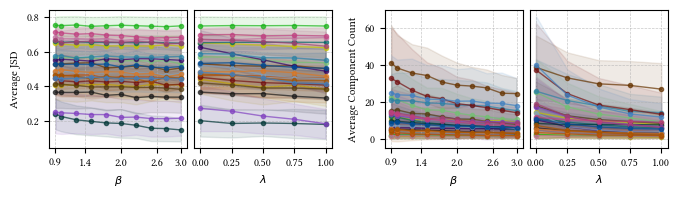

In [ ]:
measure = 'jsd'
summaries = []
for name in uci_datasets_info.keys():
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [256, 512, 1024, 2048]
    
    for pocket_size in pocket_sizes:
        file = f'./results/rebuttal/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)
            
            summary_df = pd.DataFrame(results['summary'][1:], columns=results['summary'][0])
            summary_df.insert(loc=0, column='dataset', value=[name]*summary_df.shape[0])
            summary_df = summary_df[(summary_df['beta'] >= 0.9) & (summary_df['beta'] <= 3.0)]

            summaries.append(summary_df)

summary_df = pd.concat(summaries, axis=0)

width_pt = 506.295
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.40

# 2. Plotting Setup (using LaTeX styling)
plt.rcParams.update({
    'font.family': custom_font,
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1,
    'lines.markersize': 3,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

param_ticks = {
    # "alpha": [-3, -2, -1, 0, 1],
    "beta": [0.9, 1.4, 2.0, 2.6, 3.0],
    "lambda": [0, 0.25, 0.5, 0.75, 1.0]
}

# Assuming your DataFrame is named 'agg_summary' and has the columns:
# ['dataset', 'alpha', 'beta', 'lambda', 'avg_score']

fig = plt.figure(figsize=(fig_width, fig_height))

subfigs = fig.subfigures(1, 2, wspace=-0.08)

axes = [None, None]
axes[0] = subfigs[0].subplots(1, 2, sharey=True, gridspec_kw={'wspace': 0.05})
axes[1] = subfigs[1].subplots(1, 2, sharey=True, gridspec_kw={'wspace': 0.05})

# parameters = ['alpha', 'beta', 'lambda']
parameters = ['beta', 'lambda']
unique_datasets = summary_df['dataset'].unique()

# Choose a colormap to distinguish the 21 datasets
# colors = plt.cm.tab20(np.linspace(0, 1, len(unique_datasets)))

beta_score = []
beta_cluster = []
lambda_score = []
lambda_cluster = []

for t, target in enumerate(['score', 'num_clusters']):
    for i, param in enumerate(parameters):
        ax = axes[t][i]
        
        # Calculate mean and std for the current parameter, grouped by dataset
        grouped = summary_df.groupby(['dataset', param])[target].agg(['mean', 'std']).reset_index()
        
        # Plot a line for each dataset
        for j, ds in enumerate(unique_datasets):
            if ds == 'sepsis_survival_primary_cohort':
                continue

            ds_data = grouped[grouped['dataset'] == ds]
            
            ds_data = ds_data.sort_values(by=param)

            if param == 'beta':
                if target == 'score':
                    beta_score.extend(ds_data[[param, 'mean']].values.tolist())
                elif target == 'num_clusters':
                    beta_cluster.extend(ds_data[[param, 'mean']].values.tolist())
            elif param == 'lambda':
                if target == 'score':
                    lambda_score.extend(ds_data[[param, 'mean']].values.tolist())
                elif target == 'num_clusters':
                    lambda_cluster.extend(ds_data[[param, 'mean']].values.tolist())
            
            # ax.plot(ds_data[param], ds_data['mean'], marker=name_map[ds][1], color=color_list[j], alpha=0.7)
            ax.plot(ds_data[param], ds_data['mean'], marker='o', color=color_list[name_map[ds][2]], alpha=0.7)
            
            ax.fill_between(
                ds_data[param], 
                ds_data['mean'] - ds_data['std'], 
                ds_data['mean'] + ds_data['std'], 
                color=color_list[name_map[ds][2]], 
                alpha=0.1
            )
        
        xlabel = fr"$\{param}$"
        if param == 'alpha':
            xlabel = fr"$\log_{{10}}{{\{param}}}$"
        ax.set_xlabel(xlabel, fontweight='bold') # Using LaTeX rendering for greek letters
        ax.set_xticks(param_ticks[param])
        ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.5)

axes[0][0].set_ylabel('Average JSD', fontweight='bold')
axes[1][0].set_ylabel('Average Component Count', fontweight='bold')
axes[0][1].tick_params(axis='y', length=0)
axes[1][1].tick_params(axis='y', length=0)

axes[0][0].set_box_aspect(1)
axes[0][1].set_box_aspect(1)
axes[1][0].set_box_aspect(1)
axes[1][1].set_box_aspect(1)

# fig.supylabel("Average JSD", fontweight='bold', x=-0.06)

# shift = 0.3
# for ax in axes[2:]:
#     pos = ax.get_position()
#     ax.set_position([pos.x0 + shift, pos.y0, pos.width, pos.height])

# fig.subplots_adjust(wspace=0.1)

# Automatically adjust internal padding
plt.tight_layout(pad=0.1)

# Save strictly to the 506.295pt width
plt.savefig('./plots/parameter_trends.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01)

/tmp/ipykernel_59823/3266906808.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


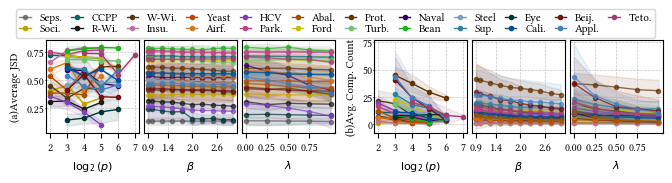

In [6]:
measure = 'jsd'
summaries = []
for name in uci_datasets_info.keys():
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [256, 512, 1024, 2048]
    
    for pocket_size in pocket_sizes:
        file = f'./results/rebuttal/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)
            
            summary_df = pd.DataFrame(results['summary'][1:], columns=results['summary'][0])
            summary_df.insert(loc=0, column='dataset', value=[name]*summary_df.shape[0])
            summary_df = summary_df[(summary_df['beta'] >= 0.9) & (summary_df['beta'] <= 3.0)]

            summaries.append(summary_df)

summary_df = pd.concat(summaries, axis=0)

width_pt = 506.295
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.40

# 2. Plotting Setup (using LaTeX styling)
plt.rcParams.update({
    'font.family': custom_font,
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1,
    'lines.markersize': 3,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

param_ticks = {
    # "alpha": [-3, -2, -1, 0, 1],
    "beta": [0.9, 1.4, 2.0, 2.6],
    "lambda": [0, 0.25, 0.5, 0.75],
    "pocket": [2, 3, 4, 5, 6, 7]
}

# Assuming your DataFrame is named 'agg_summary' and has the columns:
# ['dataset', 'alpha', 'beta', 'lambda', 'avg_score']

fig = plt.figure(figsize=(fig_width, fig_height))

subfigs = fig.subfigures(1, 2, wspace=-0.12)

axes = [None, None]
axes[0] = subfigs[0].subplots(1, 3, sharey=True, gridspec_kw={'wspace': 0.05})
axes[1] = subfigs[1].subplots(1, 3, sharey=True, gridspec_kw={'wspace': 0.05})

# parameters = ['alpha', 'beta', 'lambda']
parameters = ['beta', 'lambda']
unique_datasets = summary_df['dataset'].unique()

# Choose a colormap to distinguish the 21 datasets
# colors = plt.cm.tab20(np.linspace(0, 1, len(unique_datasets)))

beta_score = []
beta_cluster = []
lambda_score = []
lambda_cluster = []

arts = []
for t, target in enumerate(['score', 'num_clusters']):
    for i, param in enumerate(parameters):
        ax = axes[t][i+1]
        
        # Calculate mean and std for the current parameter, grouped by dataset
        grouped = summary_df.groupby(['dataset', param])[target].agg(['mean', 'std']).reset_index()
        
        # Plot a line for each dataset
        for j, ds in enumerate(unique_datasets):
            ds_data = grouped[grouped['dataset'] == ds]
            
            ds_data = ds_data.sort_values(by=param)
            
            art, = ax.plot(ds_data[param], ds_data['mean'], marker='o', color=color_list[name_map[ds][2]], alpha=0.7, label=f'{name_map[ds][0]}')
            
            if ds == 'sepsis_survival_primary_cohort' and len(arts) == 0:
                arts.append(art)

            ax.fill_between(
                ds_data[param], 
                ds_data['mean'] - ds_data['std'], 
                ds_data['mean'] + ds_data['std'], 
                color=color_list[name_map[ds][2]], 
                alpha=0.1
            )
        
        xlabel = fr"$\{param}$"
        if param == 'alpha':
            xlabel = fr"$\log_{{10}}{{\{param}}}$"
        ax.set_xlabel(xlabel, fontweight='bold') # Using LaTeX rendering for greek letters
        ax.set_xticks(param_ticks[param])
        ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.5)

for size_to_plot in [10000, 50000, 100000, 250000]:
    for name in uci_datasets_info.keys():
        if name == 'ct_slices_axial':
            continue

        if uci_datasets_info[name]['size'] <= 10000:
            if size_to_plot != 10000:
                continue 
            pocket_sizes = [4, 8, 16, 32]
        elif uci_datasets_info[name]['size'] <= 50000:
            if size_to_plot != 50000:
                continue
            pocket_sizes = [8, 16, 32, 64]
        elif uci_datasets_info[name]['size'] <= 100000:
            if size_to_plot != 100000:
                continue
            pocket_sizes = [16, 32, 64, 128]
        # elif uci_datasets_info[name]['size'] <= 200000:
        #     if size_to_plot != 250000:
        #         continue
        #     pocket_sizes = [256, 512, 1024, 2048]
        else:
            continue

        measure = 'jsd'
        summary = [['pocket', 'alpha', 'beta', 'lambda', 'score', 'num_nodes', 'num_clusters', 'runtime']]
        for pocket_size in pocket_sizes:
            file = f'./results/rebuttal/{name}_p{pocket_size}_{measure}.pkl'
            if os.path.isfile(file):
                with open(file, 'rb') as f:
                    results = pickle.load(f)
                    for summary_item in results['summary'][1:]:
                        row = [pocket_size]
                        row.extend(summary_item)
                        summary.append(row)
            
        summary_df = pd.DataFrame(summary[1:], columns=summary[0])
        summary_df['pocket'] = np.log2(summary_df['pocket'])

        avg_values = summary_df.groupby(['pocket']).agg(
            avg_score=('score', 'mean'),
            std_score=('score', 'std'),
            avg_cluster=('num_clusters', 'mean'),
            std_cluster=('num_clusters', 'std')
        ).reset_index()

        # print(color_list[color_i])
        art, = axes[0][0].plot(avg_values['pocket'], avg_values['avg_score'], label=f'{name_map[name][0]}', marker='o', color=color_list[name_map[name][2]])
        axes[0][0].fill_between(avg_values['pocket'], avg_values['avg_score'] - avg_values['std_score'], avg_values['avg_score'] + avg_values['std_score'], color=color_list[name_map[name][2]], alpha=0.1)
        arts.append(art)

        axes[1][0].plot(avg_values['pocket'], avg_values['avg_cluster'], label=f'{name_map[name][0]}', marker='o', color=color_list[name_map[name][2]])
        axes[1][0].fill_between(avg_values['pocket'], avg_values['avg_cluster'] - avg_values['std_cluster'], avg_values['avg_cluster'] + avg_values['std_cluster'], color=color_list[name_map[name][2]], alpha=0.1)

axes[0][0].set_xlabel(r'$\log_2\left(p\right)$', fontweight='bold')
axes[1][0].set_xlabel(r'$\log_2\left(p\right)$', fontweight='bold')

axes[0][0].set_xticks(param_ticks['pocket'])
axes[0][0].grid(True, linestyle='--', alpha=0.7, linewidth=0.5)

axes[1][0].set_xticks(param_ticks['pocket'])
axes[1][0].grid(True, linestyle='--', alpha=0.7, linewidth=0.5)

axes[0][0].set_ylabel('(a)Average JSD', fontweight='bold')
axes[1][0].set_ylabel('(b)Avg. Comp. Count', fontweight='bold')
axes[0][1].tick_params(axis='y', length=0)
axes[0][2].tick_params(axis='y', length=0)
axes[1][1].tick_params(axis='y', length=0)
axes[1][2].tick_params(axis='y', length=0)

axes[0][0].set_box_aspect(1)
axes[0][1].set_box_aspect(1)
axes[0][2].set_box_aspect(1)
axes[1][0].set_box_aspect(1)
axes[1][1].set_box_aspect(1)
axes[1][2].set_box_aspect(1)

axes[0][0].tick_params(axis='y', pad=0.01, length=0.75)
axes[1][0].tick_params(axis='y', pad=0.01, length=0.75)

# subfigs[0].supxlabel("(a)", fontweight='bold', y=0.13)
# subfigs[1].supxlabel("(b)", fontweight='bold', y=0.13)

leg = fig.legend(
    handles=arts,
    loc='upper center', 
    bbox_to_anchor=(0.48, 0.77), 
    ncol=12, 
    borderaxespad=0.0,
    handlelength=1.0, 
    borderpad=0.3,
    labelspacing=0.01,   
    columnspacing=0.81   
)

# fig.subplots_adjust(wspace=0.05)

plt.tight_layout()

# Save strictly to the 506.295pt width
plt.savefig('./plots/rebuttal/parameter_all_trends.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01)

In [ ]:
# --------------------------------------------------------------------------
# config
# --------------------------------------------------------------------------
measure      = 'jsd'
results_dir  = './results/rebuttal'      # dir holding the beta/lambda sweeps
out_dir      = './plots/rebuttal'

target       = 'num_clusters'              # 'score' | 'num_clusters' | 'runtime' | ...
cbar_label   = {'score': 'Avg. JSD',
                'num_clusters': 'Avg. Comp. Count',
                'runtime': 'Runtime (s)'}.get(target, target)

beta_range   = (0.9, 3.0)
alpha_fix    = None                 # None -> average over alpha; else pin a value
cmap         = 'viridis'
annotate     = False                # write the value inside each cell
mark_best    = True                 # star the argmax cell of each panel
show_title   = True                 # dataset name as a figure title
n_xticks     = 4                    # approx. number of beta ticks shown
n_yticks     = 4                    # approx. number of lambda ticks shown


def pocket_sizes_for(n):
    if n <= 10_000:
        return [4, 8, 16, 32]
    if n <= 50_000:
        return [8, 16, 32, 64]
    if n <= 100_000:
        return [16, 32, 64, 128]
    if n <= 250_000:
        return [256, 512, 1024, 2048]
    return []


# --------------------------------------------------------------------------
# load: heat[dataset][p] = DataFrame (index = lambda, columns = beta)
# --------------------------------------------------------------------------
heat = {}
for name, info in uci_datasets_info.items():
    for pocket_size in pocket_sizes_for(info['size']):
        file = f'{results_dir}/{name}_p{pocket_size}_{measure}.pkl'
        if not os.path.isfile(file):
            continue

        with open(file, 'rb') as f:
            results = pickle.load(f)

        df = pd.DataFrame(results['summary'][1:], columns=results['summary'][0])
        df = df[(df['beta'] >= beta_range[0]) & (df['beta'] <= beta_range[1])]
        if alpha_fix is not None and 'alpha' in df.columns:
            df = df[np.isclose(df['alpha'], alpha_fix)]
        if df.empty:
            continue

        grid = (df.pivot_table(index='lambda', columns='beta',
                               values=target, aggfunc='mean')
                  .sort_index()
                  .sort_index(axis=1))
        heat.setdefault(name, {})[pocket_size] = grid


# --------------------------------------------------------------------------
# style (matches the trend figure)
# --------------------------------------------------------------------------
width_pt      = 506.295
inches_per_pt = 1.0 / 72.27
fig_width     = width_pt * inches_per_pt

plt.rcParams.update({
    'font.family': custom_font,
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'lines.linewidth': 1,
    'lines.markersize': 3,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


def plot_dataset_heatmaps(name, share_scale='dataset'):
    """One figure for `name`: a beta x lambda heatmap per pocket size.

    share_scale='dataset' -> one colour scale + one colourbar for the figure
    share_scale='panel'   -> each panel normalised (and coloured) on its own
    """
    pockets = sorted(heat[name])
    ncols   = len(pockets)
    panel   = fig_width / (ncols + 0.6)        # leave room for the colourbar

    fig, axes = plt.subplots(
        1, ncols,
        figsize=(fig_width, panel * 1.35),
        squeeze=False, constrained_layout=True,
    )
    axes = axes[0]

    if share_scale == 'dataset':
        vals = np.concatenate([heat[name][p].values.ravel() for p in pockets])
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)

    im = None
    for c, p in enumerate(pockets):
        ax = axes[c]
        g = heat[name][p]
        betas, lambdas = g.columns.to_numpy(), g.index.to_numpy()

        if share_scale == 'panel':
            vmin, vmax = np.nanmin(g.values), np.nanmax(g.values)
        span = max(vmax - vmin, 1e-12)

        im = ax.imshow(g.values, origin='lower', aspect='auto', cmap=cmap,
                       vmin=vmin, vmax=vmax, interpolation='nearest')

        xstep = max(1, int(np.ceil(len(betas) / n_xticks)))
        ystep = max(1, int(np.ceil(len(lambdas) / n_yticks)))
        ax.set_xticks(np.arange(len(betas))[::xstep])
        ax.set_yticks(np.arange(len(lambdas))[::ystep])
        ax.set_xticklabels([f'{b:g}' for b in betas[::xstep]])
        ax.set_yticklabels([f'{l:g}' for l in lambdas[::ystep]] if c == 0 else [])
        ax.tick_params(length=0.75, pad=1.5)
        ax.set_title(fr'$p = {p}$', pad=2, fontweight='bold')
        ax.set_xlabel(r'$\beta$', fontweight='bold', labelpad=1)
        if c == 0:
            ax.set_ylabel(r'$\lambda$', fontweight='bold', labelpad=1)

        if mark_best and np.isfinite(g.values).any():
            bi, bj = np.unravel_index(np.nanargmax(g.values), g.shape)
            ax.scatter(bj, bi, marker='*', s=18, facecolor='none',
                       edgecolor='white', linewidth=0.6)

        if annotate:
            for i in range(g.shape[0]):
                for j in range(g.shape[1]):
                    v = g.values[i, j]
                    if not np.isfinite(v):
                        continue
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=4,
                            color='white' if (v - vmin) / span < 0.5 else 'black')

        if share_scale == 'panel':
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
            cb.ax.tick_params(length=0.75, pad=1, labelsize=6)
            if c == ncols - 1:
                cb.set_label(cbar_label, fontsize=7)

    if share_scale != 'panel' and im is not None:
        cb = fig.colorbar(im, ax=list(axes), fraction=0.018, pad=0.01)
        cb.ax.tick_params(length=0.75, pad=1, labelsize=6)
        cb.set_label(cbar_label, fontsize=7)

    if show_title:
        fig.suptitle(name_map[name][0], fontweight='bold', fontsize=8)

    return fig


# --------------------------------------------------------------------------
# driver: one PDF per dataset
# --------------------------------------------------------------------------
os.makedirs(out_dir, exist_ok=True)

for name in [n for n in uci_datasets_info if n in heat]:
    fig = plot_dataset_heatmaps(name)
    fig.savefig(f'{out_dir}/beta_lambda_{name}_{target}_{measure}.pdf',
                format='pdf', bbox_inches='tight', pad_inches=0.01)
    plt.close(fig)

# single dataset, e.g. while tuning the look:
# fig = plot_dataset_heatmaps('sepsis_survival_primary_cohort')

In [203]:
beta_scores = np.array(beta_score)
beta_cluster = np.array(beta_cluster)
lambda_scores = np.array(lambda_score)
lambda_cluster = np.array(lambda_cluster)

beta_score_cc = np.corrcoef(beta_scores, rowvar=False)
beta_cluster_cc = np.corrcoef(beta_cluster, rowvar=False)
lambda_score_cc = np.corrcoef(lambda_scores, rowvar=False)
lambda_cluster_cc = np.corrcoef(lambda_cluster, rowvar=False)

print(beta_score_cc)
print(beta_cluster_cc)
print(lambda_score_cc)
print(lambda_cluster_cc)

[[ 1.         -0.04983969]
 [-0.04983969  1.        ]]
[[ 1.         -0.20881577]
 [-0.20881577  1.        ]]
[[ 1.         -0.10547277]
 [-0.10547277  1.        ]]
[[ 1.         -0.32762772]
 [-0.32762772  1.        ]]


In [6]:
rows = [['dataset', 'jsd']]
for name in uci_datasets_info.keys():
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [512, 1024, 2048]

    the_best = []
    for measure in ['jsd']:
        is_all_done = True
        best_of_each = []
        for pocket_size in pocket_sizes:
            file = f'./results/ablation_rebuttal/{name}_p{pocket_size}.pkl'
            if os.path.isfile(file):
                with open(file, 'rb') as f:
                    results = pickle.load(f)
                    # the_values = [results['best_scores'][0]]
                    # the_values.extend(list(results['best_configs'][0])[1:])
                    # best_of_each.append(the_values)
                    # best_ratio = -float('inf')
                    # best_i = 0
                    # for i in range(3):
                    #     ratio = results['best_scores'][i] / len(results['best_details'][i]['clusters'])
                    #     if ratio > best_ratio:
                    #         best_ratio = ratio
                    #         best_i = i
                    
                    best_i = 0
                    best_of_each.append(results['best_scores'][best_i])
            else:
                is_all_done = False
                break
        
        if is_all_done:
            # the_best.append(max(best_of_each, key=lambda x: x[0]))
            the_best.append(max(best_of_each))
    
    if len(the_best) == 1:
        new_row = [name]
        new_row.extend(the_best)
        rows.append(new_row)

ablation_df = pd.DataFrame(rows[1:], columns=rows[0])

In [ ]:
combined_df = best_df[['dataset', 'jsd']].merge(ablation_df[['dataset', 'jsd']], on='dataset', how='left', suffixes=('_scout', '_scout_solo'))
combined_df = combined_df.round(3)
combined_df = combined_df.fillna(-1)
combined_df

In [ ]:
width_pt = 241.14749
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.75

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=300)

x = np.array(range(len(combined_df['dataset']))) * 2
width = np.ones(len(combined_df['dataset'])) * 0.7

# bar_colors = [color_list[name_map[ds][2]] for ds in combined_df['dataset']]
bars_scout = ax.bar(
    x - (width/2), 
    combined_df['jsd_scout'], 
    width, 
    color=CB_palette['CBcyan'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='////',
    label='Scout',
    align='center'
)
               
bars_solo = ax.bar(
    x + (width/2), 
    combined_df['jsd_scout_solo'], 
    width, 
    color=CB_palette['CBpurple'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='....',
    label='Scout-Solo',
    align='center'
)

ax.set_ylabel('JSD', fontweight='bold')
ax.set_xlabel('Dataset', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([name_map[ds][0] for ds in combined_df['dataset']], rotation=90)

ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.25, axis='y')

# ax.set_box_aspect(1)

legend_elements = [
    Patch(facecolor='white', edgecolor='black', hatch='////', label='Scout'),
    Patch(facecolor='white', edgecolor='black', hatch='....', label='Scout-Solo')
]
ax.legend(handles=[bars_scout, bars_solo], loc='best', framealpha=0.25)

# 6. Export without white margins
plt.tight_layout(pad=0.1)
plt.savefig('./plots/rebuttal/scout_comparisons.pdf', format='pdf', bbox_inches='tight', pad_inches=0.0)

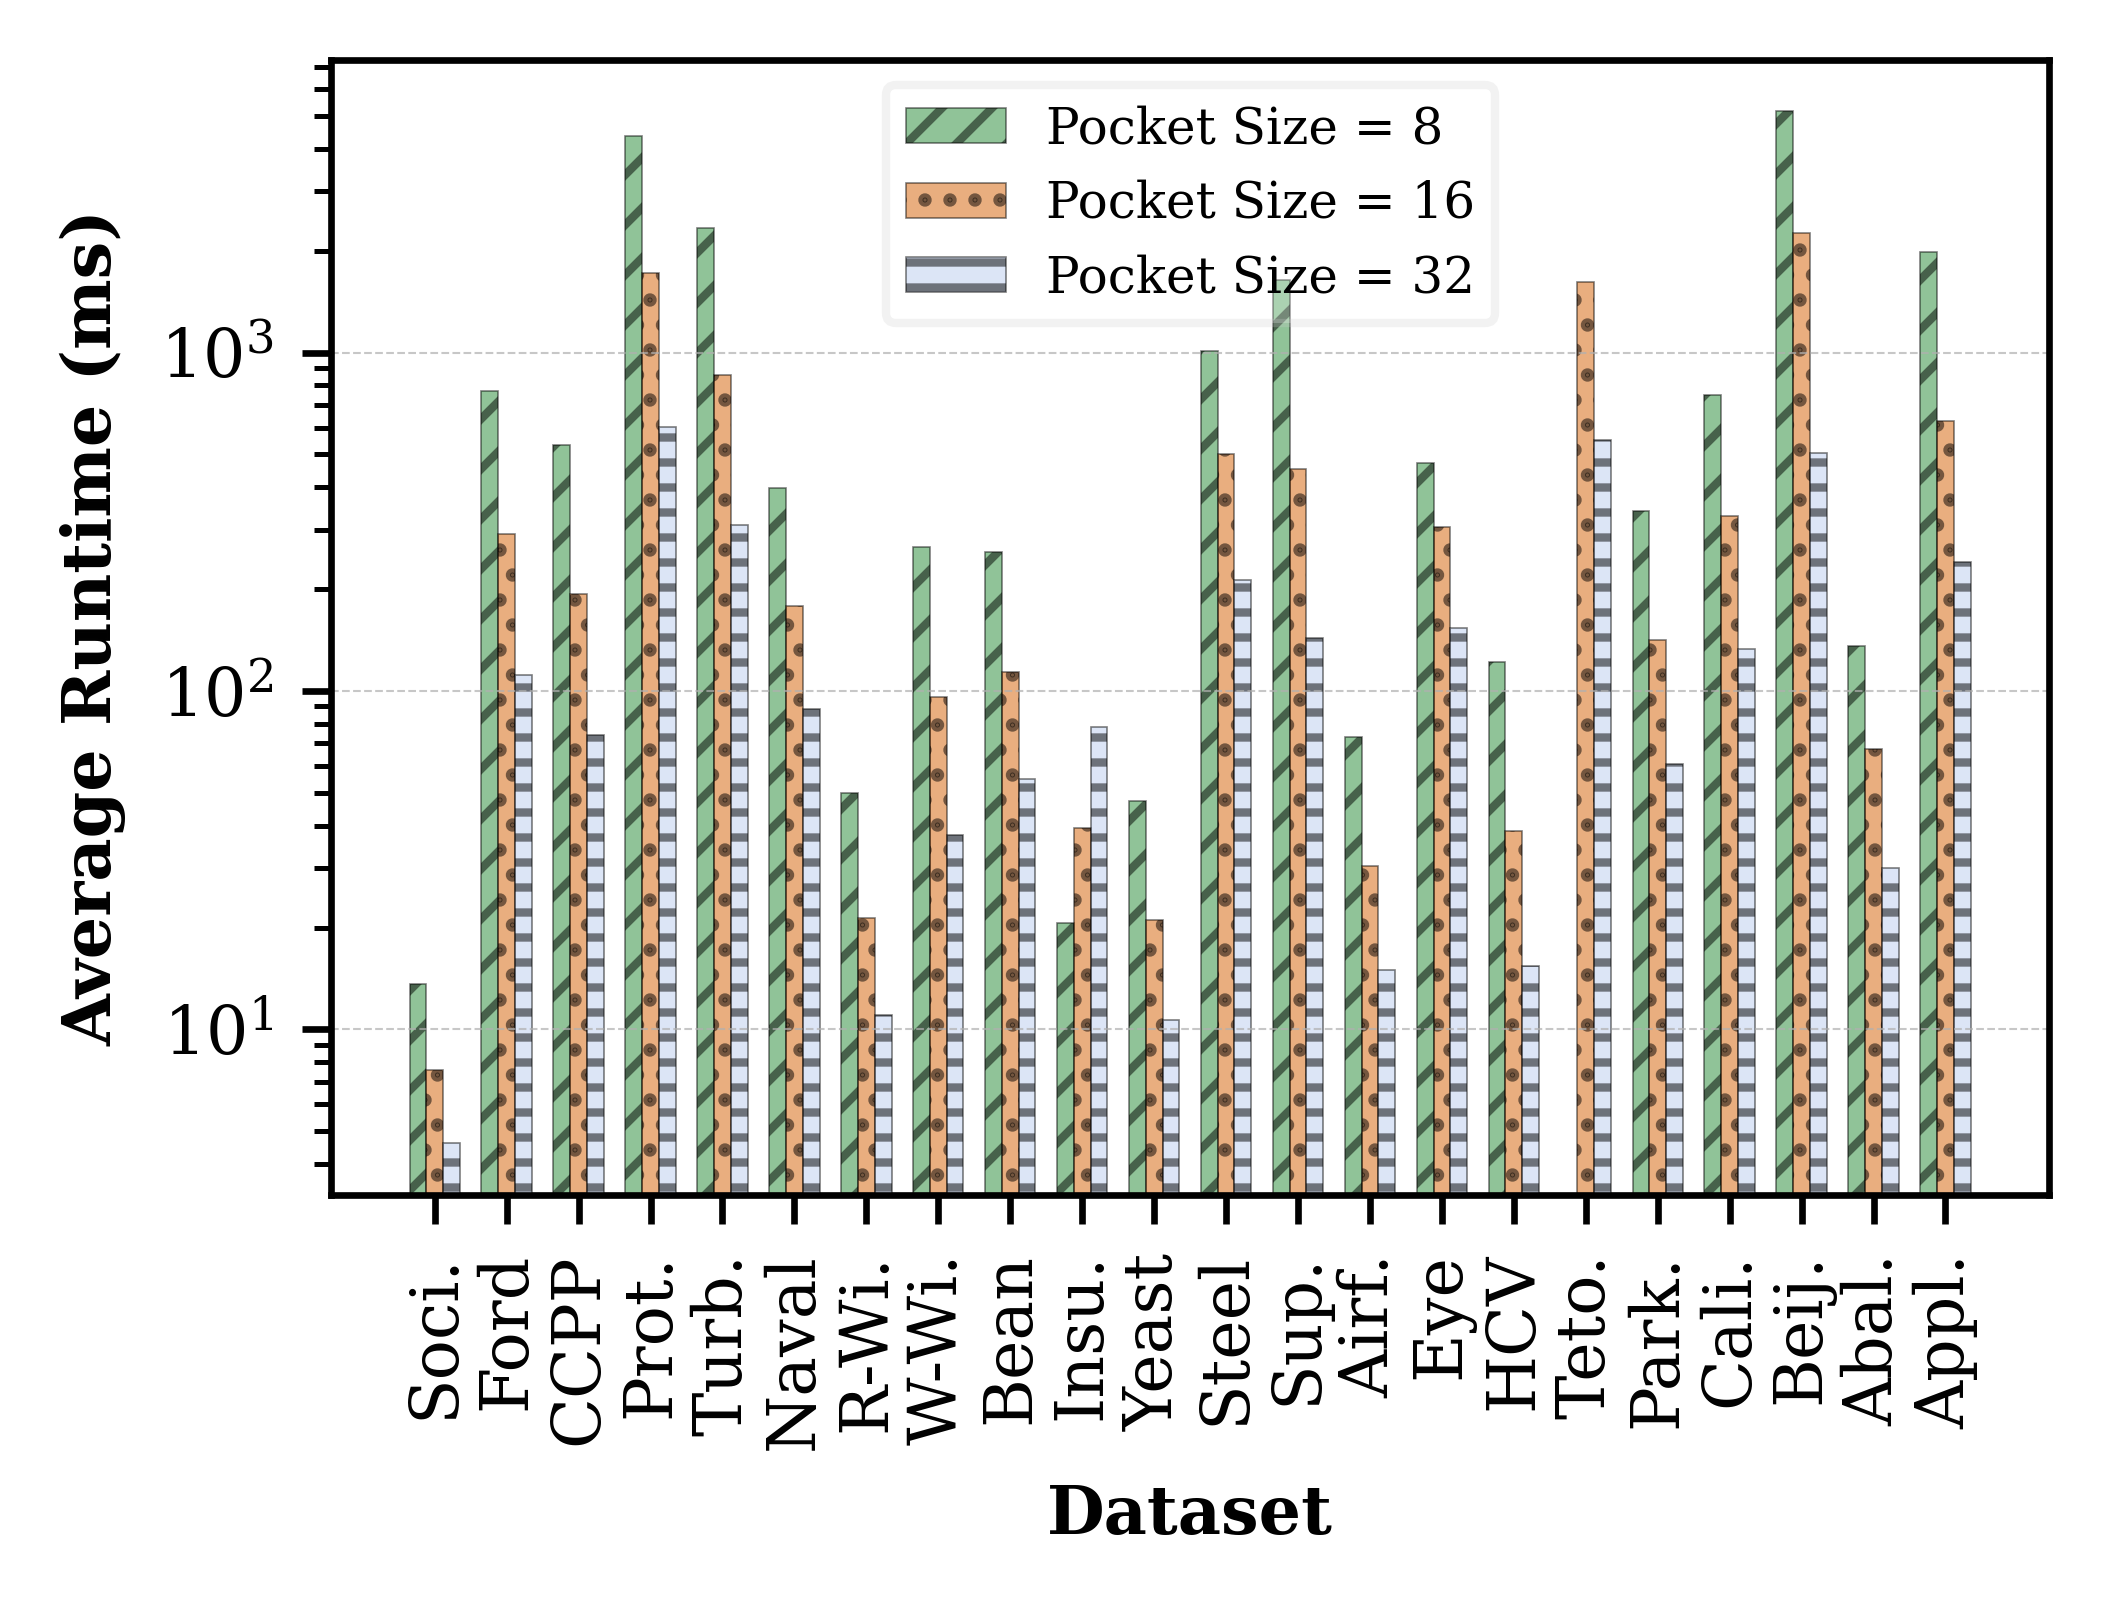

In [ ]:
the_names = []

p8_avg = []
p16_avg = []
p32_avg = []

p8_std = []
p16_std = []
p32_std = []

for name in uci_datasets_info.keys():
    if name == 'ct_slices_axial':
        continue

    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32] 
    else:
        continue

    df = pd.read_csv(f'./datasets/{name}.csv', delimiter=uci_datasets_info[name]['delim'])
    df, mapping, _ = preprocess_dataframe(df, uci_datasets_info[name]['target_variable'][0], uci_datasets_info[name]['categorical_variables'], uci_datasets_info[name]['id_variables'])
    num_rows, num_cols = df.shape

    measure = 'jsd'
    summary = [['pocket', 'runtime']]
    for pocket_size in pocket_sizes:
        file = f'./results/rebuttal/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)
                for summary_item in results['summary'][1:]:
                    row = [pocket_size]
                    row.extend([summary_item[-1]])
                    summary.append(row)
        
    summary_df = pd.DataFrame(summary[1:], columns=summary[0])

    avg_runtime = summary_df.groupby(['pocket']).agg(
        avg_runtime=('runtime', 'mean'),
        std_runtime=('runtime', 'std')
    ).reset_index()

    avg_runtime['avg_runtime'] = avg_runtime['avg_runtime'] * 1e3
    avg_runtime['std_runtime'] = avg_runtime['std_runtime'] * 1e3

    avg_list = avg_runtime['avg_runtime'].tolist()
    std_list = avg_runtime['std_runtime'].tolist()

    if len(avg_list) > 2:
        p8_avg.append(avg_list[0])
        p16_avg.append(avg_list[1])
        p32_avg.append(avg_list[2])

        p8_std.append(std_list[0])
        p16_std.append(std_list[1])
        p32_std.append(std_list[2])
    elif len(avg_list) == 2:
        p8_avg.append(0)
        p16_avg.append(avg_list[0])
        p32_avg.append(avg_list[1])
        
        p8_std.append(0)
        p16_std.append(std_list[0])
        p32_std.append(std_list[1])

    the_names.append(name)


width_pt = 241.14749
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.75

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=600)

x = np.array(range(len(the_names))) * 3
width = np.ones(len(the_names)) * 0.7

bars_p8 = ax.bar(
    x - width, 
    p8_avg, 
    width, 
    # yerr=p8_std,
    color=CB_palette['CBgreen'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='////',
    label='Pocket Size = 8',
    align='center'
)
               
bars_p16 = ax.bar(
    x, 
    p16_avg, 
    width, 
    # yerr=p16_std,
    color=CB_palette['CBorange'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='....',
    label='Pocket Size = 16',
    align='center'
)

bars_p32 = ax.bar(
    x + width, 
    p32_avg, 
    width, 
    # yerr=p32_std,
    color=CB_palette['CBpaleblue'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='----',
    label='Pocket Size = 32',
    align='center'
)

ax.set_yscale('log')

ax.set_ylabel('Average Runtime (ms)', fontweight='bold')
ax.set_xlabel('Dataset', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([name_map[ds][0] for ds in the_names], rotation=90)

ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.25, axis='y')

ax.legend(handles=[bars_p8, bars_p16, bars_p32], loc='best', framealpha=0.25)

# 6. Export without white margins
plt.tight_layout(pad=0.1)
plt.savefig(f'./plots/runtimes_bars.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01)

In [ ]:
rows = [['dataset', 'jsd']]
name = 'insurance'
pocket_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
the_best = []
for measure in ['jsd']:
    # is_all_done = True
    best_of_each = []
    for pocket_size in pocket_sizes:
        file = f'./results/rebuttal/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)
                best_i = 0
                best_of_each.append(results['best_scores'][best_i])
                print(results['best_scores'][best_i])
        # else:
        #     is_all_done = False
        #     break
    
    # if is_all_done:
    #     # the_best.append(max(best_of_each, key=lambda x: x[0]))
    the_best.append(max(best_of_each))

if len(the_best) == 1:
    new_row = [name]
    new_row.extend(the_best)
    rows.append(new_row)

0.8030251860618591
0.8337894082069397
0.7950990796089172
0.7936888337135315
0.7927003502845764
0.7926884293556213
0.7982631921768188
0.7816648483276367


,dataset,jsd
0,insurance,0.787604
